In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import torch
import pandas as pd
import torchvision.transforms as T
from torch import nn
from torch.utils.data import DataLoader
from tqdm import tqdm
import os
import json
import math
import pickle
import matplotlib.pyplot as plt
from IPython.display import clear_output
from scipy.ndimage import gaussian_filter
from matplotlib.gridspec import GridSpec

from matplotlib.patches import Rectangle

from bioplnn.models import SpatiallyEmbeddedClassifier, SpatiallyEmbeddedAreaConfig, SpatiallyEmbeddedRNN
from bioplnn.datasets import Mazes
from bioplnn.utils import (
    initialize_dataloader,
)

maze_data_path = "./data/mazes"
checkpoint_path = "./train/checkpoints/"

# Torch setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
torch.set_float32_matmul_precision("high")

batch_size = 20

In [3]:
def prepare_rnn_weights(state_dict):
    """Remove 'rnn.' prefix from all keys in the state dict.
        Also remove any key starting with readout"""
    new_state_dict = {}
    for key, value in state_dict.items():
        if key.startswith('rnn.'):
            new_key = key[4:]  # Remove 'rnn.' prefix
            new_state_dict[new_key] = value
        elif not key.startswith('readout'):
            new_state_dict[key] = value
    return new_state_dict
    

In [4]:
def combine_activations(activations, abs=True):
    if abs:
        return torch.mean(torch.abs(activations), dim=1)
    else:
        return torch.mean(activations, dim=1)

def visualize_activations(excitatory_activations, inhibitory_activations, maze):
    excitatory_activations = combine_activations(excitatory_activations)
    inhibitory_activations = combine_activations(inhibitory_activations)
    
    combined_activations = torch.sum(excitatory_activations - inhibitory_activations, dim = 0)
    return combined_activations

In [8]:
train_loader, test_loader = initialize_dataloader(
    seed=42, root="./data/mazes/", batch_size=batch_size, dataset="mazes"
)
inputs, labels = next(iter(test_loader))
mazes = Mazes(maze_data_path)

# Start Here

In [5]:
def load_model_and_config(wandb_name, checkpoint_path):
    """Load model configuration and instantiate models."""
    try:
        full_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        model_cfg, num_steps = full_cfg["model_config"], full_cfg["num_steps"]
    except:
        model_cfg = pickle.load(open(checkpoint_path + f"{wandb_name}.pkl", "rb"))
        num_steps = 20

    model = SpatiallyEmbeddedRNN(**model_cfg["rnn_kwargs"])
    classifier = SpatiallyEmbeddedClassifier(**model_cfg)
    mazes = Mazes(maze_data_path)
    
    return model, classifier, mazes, num_steps


def extract_weights(state_dict, excitatory, output):
    """Extract weight matrices and tau constants from state dict."""
    if excitatory:
        conv0 = state_dict["rnn.areas.0.convs.0->0.0.weight"].detach().cpu().numpy()
        e2e = state_dict["rnn.areas.0.convs.1->0.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.0"].detach().cpu().numpy()[0, :, 0, 0]
    else:
        if output:
            e2e = state_dict["rnn.areas.0.convs.2->0.0.weight"].detach().cpu().numpy()
        else:
            e2e = state_dict["rnn.areas.0.convs.1->1.0.weight"].detach().cpu().numpy()
        conv0 = state_dict["rnn.areas.0.convs.0->1.0.weight"].detach().cpu().numpy()
        taus = state_dict["rnn.areas.0.tau.1"].detach().cpu().numpy()[0, :, 0, 0]
    
    return conv0, e2e, taus

def extract_output_weights(state_dict):
    """Extract weight matrices and tau constants from state dict."""
    e2e = state_dict["rnn.areas.0.out_convs.1->out.0.weight"].detach().cpu().numpy()
    return e2e


def apply_gaussian_filter(data, sigma):
    """Apply Gaussian filter to data and return filtered data with min/max values."""
    filtered_data = gaussian_filter(data, sigma=sigma)
    return filtered_data, filtered_data.min(), filtered_data.max()


def create_activity_subplot(fig, subplot_spec, data, step, title, vmin=None, vmax=None, cmap='viridis'):
    """Create a standardized activity subplot."""
    ax = fig.add_subplot(subplot_spec)
    im = ax.imshow(data, cmap=cmap, vmin=vmin, vmax=vmax)
    ax.axis('off')
    ax.set_title(title, fontsize=8)
    return ax, im


def highlight_self_kernel(ax, is_self=False):
    """Highlight the 'self' kernel with red border or hide borders for others."""
    if is_self:
        for side in ax.spines:
            spine = ax.spines[side]
            spine.set_visible(True)
            spine.set_edgecolor('red')
            spine.set_linewidth(1.5)
    else:
        for spine in ax.spines.values():
            spine.set_visible(False)


def plot_maze_sample(fig, outer_grid, row_idx, maze_data, sample_idx, is_correct):
    """Plot maze sample with correctness indicator."""
    ax = fig.add_subplot(outer_grid[row_idx, 0])
    ax.imshow(maze_data)
    ax.set_title(f"Sample {sample_idx} {' ✓' if is_correct else ' ✗'}", fontsize=10)
    ax.axis("off")


def plot_mean_activity_grid(fig, outer_grid, row_idx, col_idx, mean_activity, step_indices, n, m):
    """Plot mean activity across all channels in a grid layout."""
    mean_sub = outer_grid[row_idx, col_idx].subgridspec(
        n, m, height_ratios=[1]*n, hspace=0, wspace=0.02
    )
    
    mean_vmin, mean_vmax = mean_activity.min(), mean_activity.max()
    mean_ims, mean_axs = [], []
    
    for k, step in enumerate(step_indices):
        r, c = divmod(k, m)
        ax, im = create_activity_subplot(
            fig, mean_sub[r, c], mean_activity[step], 
            step, f"S{step}", mean_vmin, mean_vmax
        )
        mean_ims.append(im)
        mean_axs.append(ax)
    
    # Add column title
    ax_title = fig.add_subplot(outer_grid[0, col_idx])
    ax_title.axis('off')
    ax_title.set_title("Mean Activity", fontsize=20, pad=10, fontweight='bold')
    
    return mean_ims, mean_axs

def plot_channel_activity(
    fig, outer, row_idx, col_idx,
    act, ch_idx, step_idxs, n, m,
    input_filter, tau, kernels, sigma_filter,
    show_kernels=True
):
    """
    Per-channel cell with a *top title row* centered over the channel,
    then an n×m activity grid, and (optionally) a kernels grid.
    """

    # --- resolve tau value (scalar or vector) ---
    if torch.is_tensor(tau):
        tau_val = tau.item() if tau.ndim == 0 else float(tau[ch_idx])
    else:
        tau_val = float(tau) if np.ndim(tau) == 0 else float(tau[ch_idx])

    # --- normalize act to numpy; accept (T,H,W) or (T,C,H,W) ---
    A = act.detach().cpu().numpy() if isinstance(act, torch.Tensor) else act
    if A.ndim == 4:   # (T, C, H, W)
        imgs = A[step_idxs, ch_idx]          # (n*m, H, W)
    elif A.ndim == 3: # (T, H, W)
        imgs = A[step_idxs]                  # (n*m, H, W)
    else:
        raise ValueError(f"Unsupported act shape {A.shape}; expected (T,H,W) or (T,C,H,W).")

    # --- layout: [title] + [activity] (+ [kernels])
    if show_kernels:
        inner = outer[row_idx, col_idx].subgridspec(
            3, 1, height_ratios=[0.18, 1.0, 0.35], hspace=0.10
        )
        idx_title, idx_act, idx_ker = 0, 1, 2
    else:
        inner = outer[row_idx, col_idx].subgridspec(
            2, 1, height_ratios=[0.18, 1.0], hspace=0.08
        )
        idx_title, idx_act = 0, 1

    # ===== Title row (centered over the channel) =====
    ax_title = fig.add_subplot(inner[idx_title])
    ax_title.text(
        0.5, 0.5, f"Channel {ch_idx}  (τ={tau_val:.2f})",
        ha='center', va='center', fontsize=20, fontweight='bold'
    )
    ax_title.axis('off')

    # ===== Activity grid =====
    vmin = float(np.nanmin(imgs)); vmax = float(np.nanmax(imgs))
    if not np.isfinite(vmin) or not np.isfinite(vmax) or vmin == vmax:
        vmin, vmax = 0.0, 1.0

    act_spec = inner[idx_act].subgridspec(n, m, wspace=0.04, hspace=0.04)
    for i in range(n * m):
        r, c = divmod(i, m)
        ax = fig.add_subplot(act_spec[r, c])
        ax.imshow(imgs[i], cmap="viridis", vmin=vmin, vmax=vmax, interpolation="nearest")
        ax.set_xticks([]); ax.set_yticks([])

    # ===== Kernels grid (optional) =====
    if show_kernels:
        ker_list = [gaussian_filter(k, sigma=sigma_filter) for k in kernels]
        all_vals = np.concatenate([k.ravel() for k in ker_list])
        wmin, wmax = float(all_vals.min()), float(all_vals.max())
        if wmin == wmax:
            wmin, wmax = wmin - 1e-6, wmax + 1e-6

        K = len(ker_list)
        k_cols = int(np.ceil(np.sqrt(K))); k_rows = int(np.ceil(K / k_cols))
        ker_spec = inner[idx_ker].subgridspec(k_rows, k_cols, wspace=0.02, hspace=0.02)

        for k_idx, ker in enumerate(ker_list):
            rr, cc = divmod(k_idx, k_cols)
            axk = fig.add_subplot(ker_spec[rr, cc])
            axk.imshow(ker, cmap="viridis", vmin=wmin, vmax=wmax, interpolation="nearest")
            axk.set_xticks([]); axk.set_yticks([])
            if "highlight_self_kernel" in globals():
                highlight_self_kernel(axk, is_self=(k_idx == ch_idx))

# Evaluate

In [6]:
# ——— User‐set paths & names ———
# Identity
# wandb_name    = "twilight-spaceship-341"
# checkpoint    = 390    

# wandb_name = "happy-microwave-331"
# checkpoint = 200

# ReLU
# wandb_name = "earnest-planet-436"
# checkpoint = 800

# Identity, Center-Excitation
# wandb_name = "rose-elevator-396"
# checkpoint = 360

# ReLU, I->I recurrence, Center-Excitation
wandb_name = "young-totem-460"
checkpoint = 480

# ReLU, with I->I recurrence, BEST
wandb_name = "golden-universe-515"
checkpoint = 320

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

try:
    state_dict = state_dict["model_state"]
except:
    pass

classifier.load_state_dict(state_dict)

/tmp/ipykernel_1960874/1610347513.py:30: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

<All keys matched successfully>

In [9]:
classifier.to(device)
classifier.eval()
total_loss = 0
correct = 0
total = 0

with torch.no_grad():
    for x, labels in tqdm(test_loader):
        x = x.to(device)
        labels = labels.to(device)
        
        logits = classifier(x, num_steps=20)
        
        _, predicted = torch.max(logits, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = correct / total
print(accuracy)

100%|██████████| 3456/3456 [01:41<00:00, 33.94it/s]

0.9947627314814815


# Plot Everything

/tmp/ipykernel_1960874/2542550299.py:34: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_locati

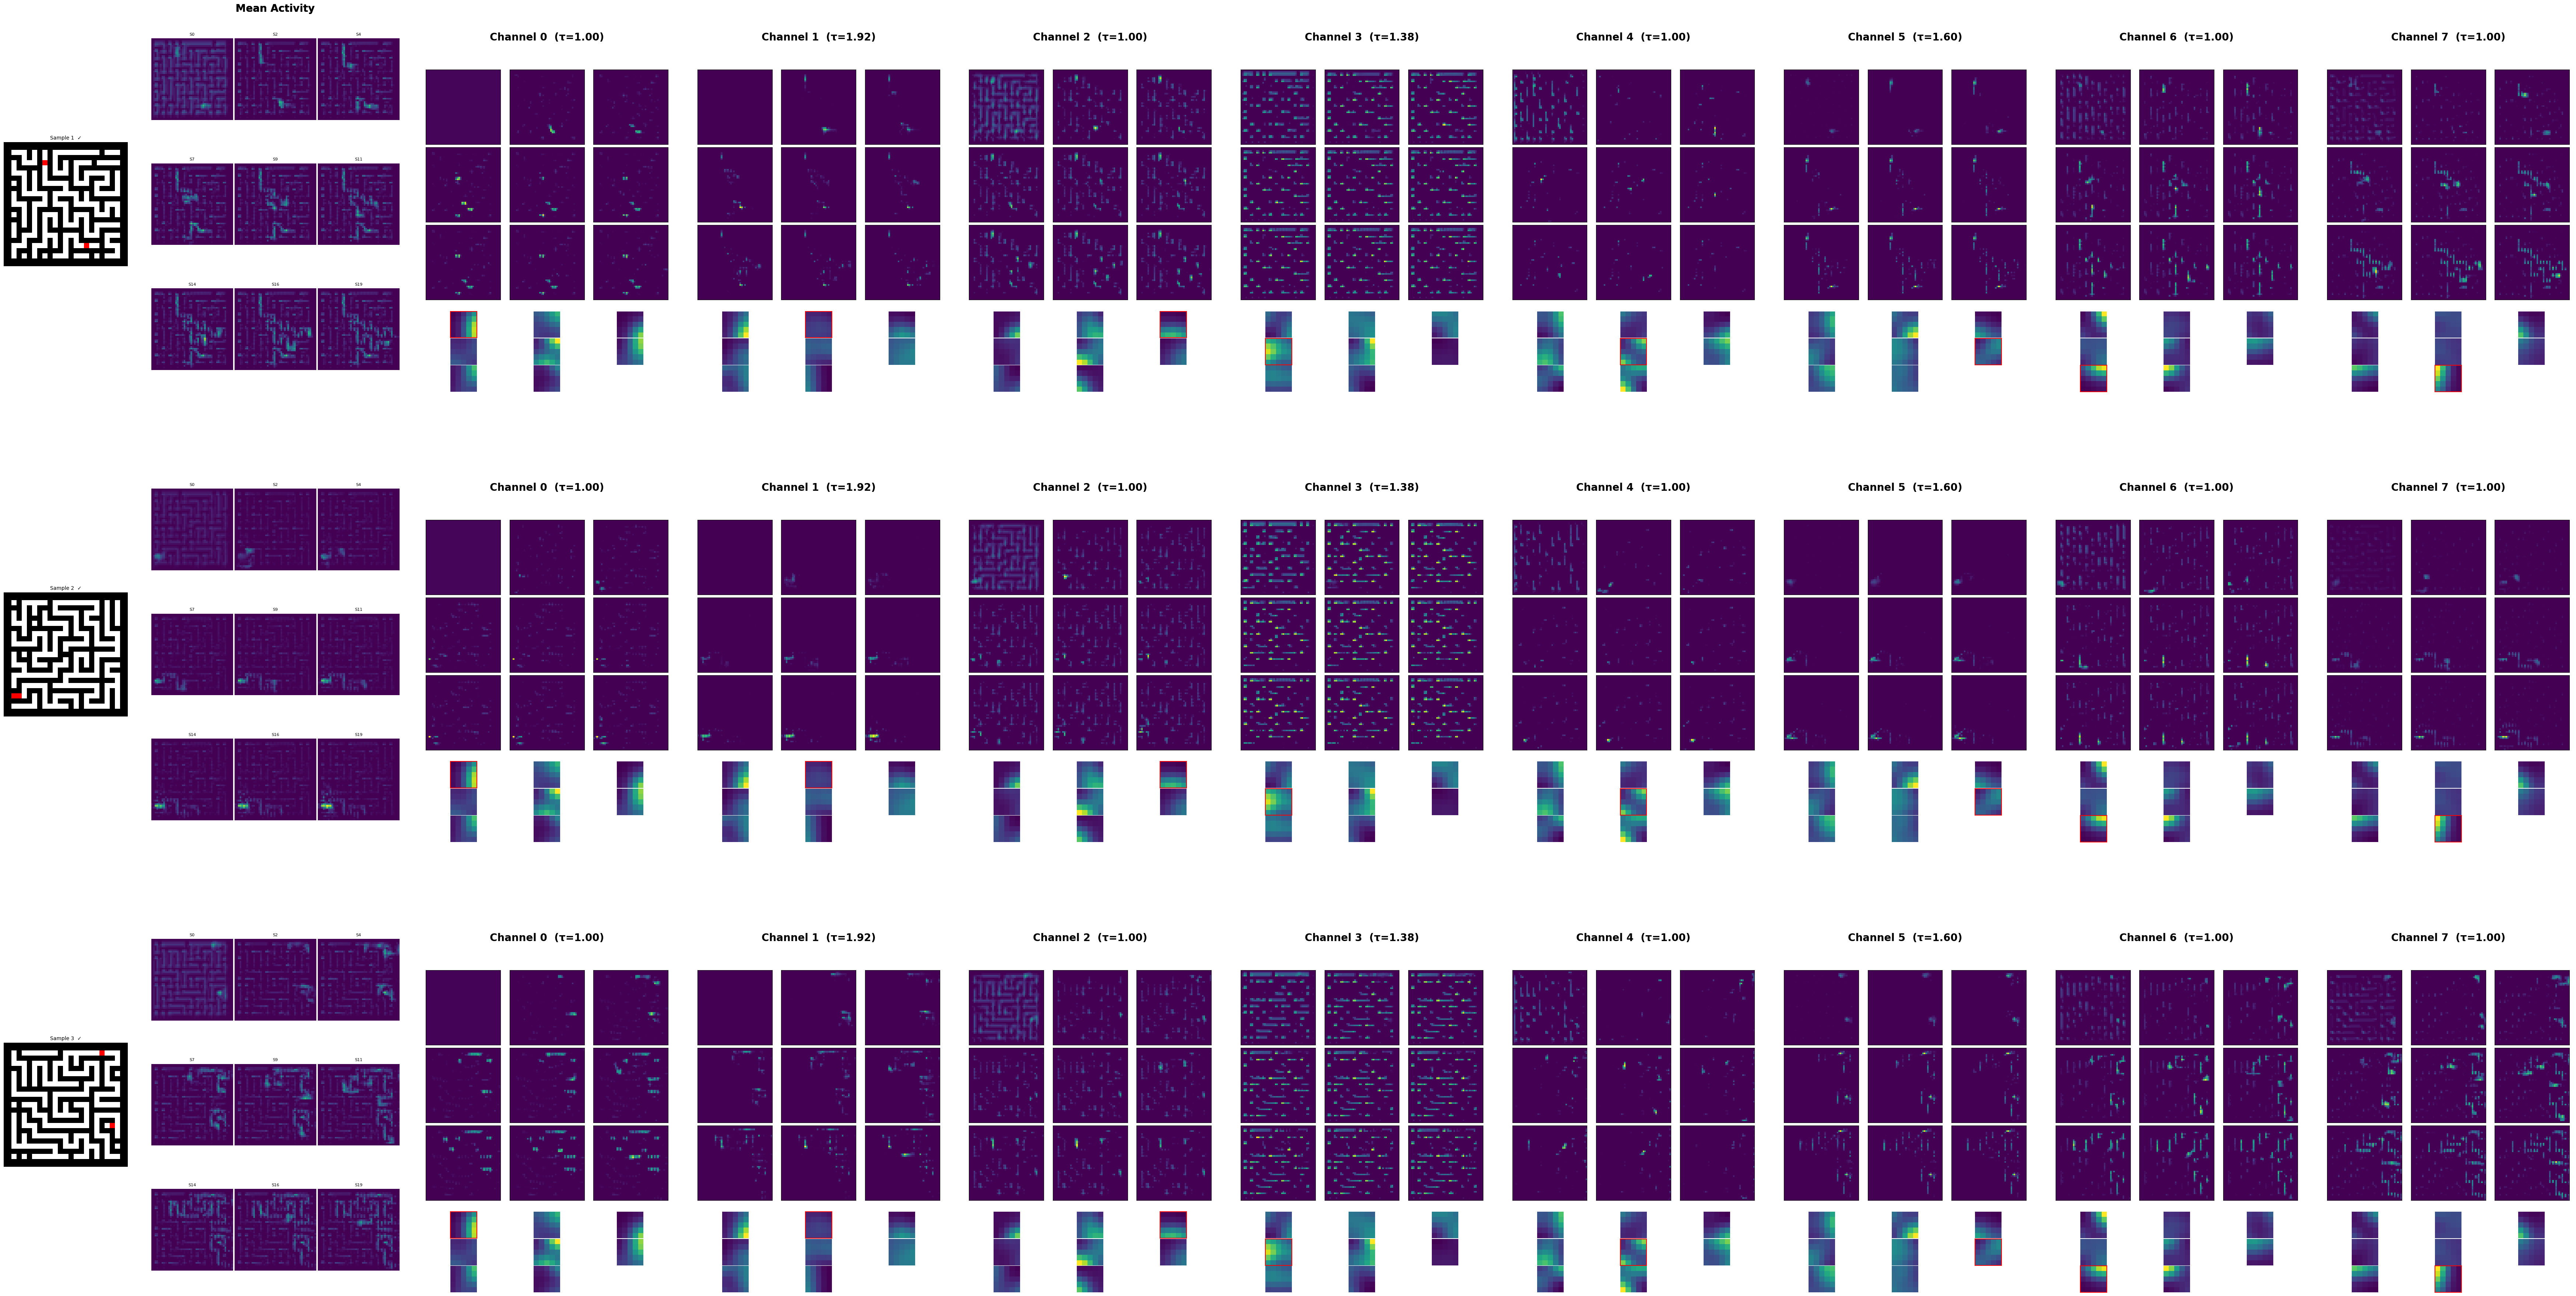

In [9]:
# ——— User‐set paths & names ———
# Identity
# wandb_name    = "twilight-spaceship-341"
# checkpoint    = 390    

# wandb_name = "happy-microwave-331"
# checkpoint = 200

# ReLU
# wandb_name = "earnest-planet-436"
# checkpoint = 800

# ReLU, with I->I recurrence
# wandb_name = "confused-haze-455"
# checkpoint = 1240

# Identity, Center-Excitation
# wandb_name = "rose-elevator-396"
# checkpoint = 360

# ReLU, I->I recurrence, Center-Excitation
wandb_name = "young-totem-460"
checkpoint = 480

# ReLU, with I->I recurrence, BEST
wandb_name = "golden-universe-515"
checkpoint = 320

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))

try:
    state_dict = state_dict["model_state"]
except:
    pass

model.load_state_dict(prepare_rnn_weights(state_dict))
classifier.load_state_dict(state_dict)

# ——— Plot settings ———
excitatory = True
input_channel = -1 # 0 is walls, -1 is starting points
plot_maze = True
n, m = 3, 3  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
output = False  # if True: kernels = e2e[:, j], else: kernels = e2e[j, :]
channels_to_plot = None #[1]  # None plots all channels, or specify list like [0, 2, 5] for specific channels
samples_to_plot = [1,2,3] #None #[12, 13] #[5, 6, 7, 8, 9, 10, 11, 12, 13] #None #[1, 2, 3, 4] #[1]  # None plots all samples, or specify list like [0, 2, 5] for specific samples
do_highlight_self_kernel = True
show_kernels_row = True

do_output_analysis = False

# ——— Extract weight‐matrices & taus ———
conv0, e2e, taus = extract_weights(state_dict, excitatory, output)
input_filters = conv0[:, input_channel]  # ⇒ (C, H, W)

# -- Cheating a bit to do output analysis --- super lazy
if do_output_analysis:
    e2e = extract_output_weights(state_dict)

# Precompute channel count and filter channels if specified
C = input_filters.shape[0]
if channels_to_plot is not None:
    # Validate channel indices
    if not all(0 <= ch < C for ch in channels_to_plot):
        raise ValueError(f"Channel indices must be between 0 and {C-1}")
    channel_indices = channels_to_plot
    C_plot = len(channel_indices)
else:
    channel_indices = list(range(C))
    C_plot = C

# Number of columns for activity: one per channel (+1 for maze)
num_cols = C_plot + 1 + (1 if plot_maze else 0)

# Filter samples if specified
if samples_to_plot is not None:
    # Validate sample indices
    if not all(0 <= s < len(inputs) for s in samples_to_plot):
        raise ValueError(f"Sample indices must be between 0 and {len(inputs)-1}")
    sample_indices = samples_to_plot
    num_inputs = len(sample_indices)
else:
    sample_indices = list(range(len(inputs)))
    num_inputs = len(inputs)

# Setup main figure
fig = plt.figure(figsize=(3 * num_cols * m, 15 * num_inputs))
# Calculate width ratios dynamically based on what we're plotting
if plot_maze:
    width_ratios = [1] + [2] + [2] * C_plot
else:
    width_ratios = [2] + [2] * C_plot

outer = fig.add_gridspec(
    num_inputs, num_cols,
    width_ratios=width_ratios,
    hspace=0.2, wspace=0.1
)

# Pre-filter kernels for consistent color scaling
full_wvmin, full_wvmax = np.inf, -np.inf
for j in channel_indices:
    kernels = e2e[:, j] if output else e2e[j, :]
    for k in range(len(kernels)):
        kernels[k] = gaussian_filter(kernels[k], sigma=sigma_filter)
    wvmin, wvmax = kernels.min(), kernels.max()
    full_wvmin = min(full_wvmin, wvmin)
    full_wvmax = max(full_wvmax, wvmax)

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx], labels[sample_idx]
    # Compute activity for sample i
    out = classifier(inp.unsqueeze(0), num_steps=num_steps)
    correct = (out.argmax(dim=1).item() == label)

    output_states, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)

    act = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]  # shape (T, C)
    
    if do_output_analysis:
        act = output_states[0][0].detach().cpu()

    T = act.shape[0]
    step_idxs = np.linspace(0, T - 1, n * m, dtype=int)

    # Plot maze if desired
    col_offset = 0
    if plot_maze:
        plot_maze_sample(fig, outer, plot_idx, mazes.tensor_to_image(inp), sample_idx, correct)
        col_offset = 1
    
    # Compute and plot mean activity
    mean_act = torch.mean(act, dim=1)
    plot_mean_activity_grid(fig, outer, plot_idx, col_offset, mean_act, step_idxs, n, m)
    col_offset += 1

    # Plot each channel
    for channel_plot_idx, j in enumerate(channel_indices):
        col = channel_plot_idx + col_offset
        kernels = e2e[:, j] if output else e2e[j, :]
        
        plot_channel_activity(
            fig, outer, plot_idx, col, act, j, step_idxs, n, m,
            input_filters[j], taus[j], kernels, sigma_filter,
            show_kernels=show_kernels_row
        )

plt.tight_layout()
plt.show()

In [ ]:
for sample_idx in sample_indices:
    inp, label = inputs[sample_idx], labels[sample_idx]
    plt.imshow(mazes.tensor_to_image(inp))
    plt.axis("off")
    plt.show()

# Just Kernels

In [13]:
model

SpatiallyEmbeddedRNN(
  (areas): ModuleList(
    (0): SpatiallyEmbeddedArea(
      (out_nonlinearity): Identity()
      (neuron_type_nonlinearity): ModuleList(
        (0-1): 2 x ReLU()
      )
      (convs): ModuleDict(
        (0->0): Sequential(
          (0): Conv2d(4, 8, kernel_size=(np.int64(5), np.int64(5)), stride=(1, 1), padding=(np.int64(2), np.int64(2)))
          (1): ReLU()
        )
        (0->1): Sequential(
          (0): Conv2d(4, 4, kernel_size=(np.int64(5), np.int64(5)), stride=(1, 1), padding=(np.int64(2), np.int64(2)))
          (1): ReLU()
        )
        (1->0): Sequential(
          (0): Conv2dRectify(8, 8, kernel_size=(np.int64(3), np.int64(3)), stride=(1, 1), padding=(np.int64(1), np.int64(1)))
          (1): ReLU()
        )
        (1->1): Sequential(
          (0): Conv2dRectify(8, 4, kernel_size=(np.int64(3), np.int64(3)), stride=(1, 1), padding=(np.int64(1), np.int64(1)))
          (1): ReLU()
        )
        (2->0): Sequential(
          (0): Conv2d

/tmp/ipykernel_1159171/925658226.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


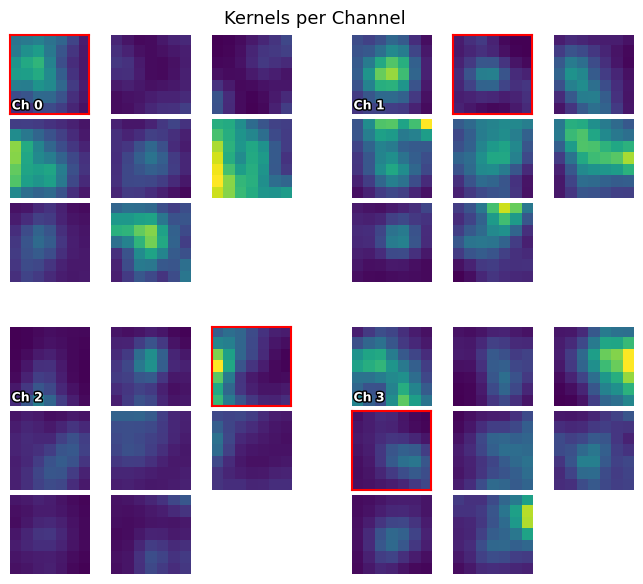

In [14]:
import math
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import numpy as np

# ——— Plot settings ———
excitatory = False
sigma_filter = 1.0  # optional blur for weights
output = True  # if True: kernels = e2e[:, j], else: kernels = e2e[j, :]
do_highlight_self_kernel = True

# --- Extract weights & build filtered_kernels as before ---
conv0, e2e, taus = extract_weights(state_dict, excitatory, output)

filtered_kernels = {}
all_channels = np.arange(e2e.shape[1] if output else e2e.shape[0])
channel_indices = all_channels if channels_to_plot is None else np.array(channels_to_plot)

for j in channel_indices:
    raw_kernels = e2e[:, j] if output else e2e[j, :]
    filtered_kernels[j] = [apply_gaussian_filter(k, sigma_filter)[0] for k in raw_kernels]

# --- Channel grid (moderately tight) ---
n_channels = len(channel_indices)
grid_cols = int(math.ceil(math.sqrt(n_channels)))
grid_rows = int(math.ceil(n_channels / grid_cols))

fig = plt.figure(figsize=(3.4 * grid_cols, 3.1 * grid_rows))  # a bit smaller than before
outer = fig.add_gridspec(grid_rows, grid_cols, wspace=0.15, hspace=0.18)

for idx, ch in enumerate(channel_indices):
    row, col = divmod(idx, grid_cols)

    kernels = filtered_kernels[ch]
    K = len(kernels)
    k_cols = int(math.ceil(math.sqrt(K)))
    k_rows = int(math.ceil(K / k_cols))

    # per-channel color scale
    all_vals = np.concatenate([k.ravel() for k in kernels])
    vmin, vmax = float(all_vals.min()), float(all_vals.max())

    inner = outer[row, col].subgridspec(k_rows, k_cols, wspace=0.06, hspace=0.06)
    for k_idx, kernel in enumerate(kernels):
        r, c = divmod(k_idx, k_cols)
        ax = fig.add_subplot(inner[r, c])
        ax.imshow(kernel, cmap='viridis', vmin=vmin, vmax=vmax, interpolation='nearest')
        ax.set_xticks([]); ax.set_yticks([])

        # optional highlight
        if 'highlight_self_kernel' in globals():
            highlight_self_kernel(ax, is_self=(k_idx == ch))

        # small in-axis label instead of a separate title axis
        if k_idx == 0:
            ax.text(0.02, 0.02, f"Ch {ch}",
                    transform=ax.transAxes, ha='left', va='bottom',
                    fontsize=9, fontweight='bold', color='white',
                    path_effects=[pe.withStroke(linewidth=2, foreground='black')])

# modest suptitle and margins (less white space, not cramped)
fig.suptitle("Kernels per Channel", fontsize=13, y=0.97)
plt.tight_layout()
plt.subplots_adjust(left=0.04, right=0.98, top=0.93, bottom=0.06)
plt.show()


In [ ]:
state_dict.keys()

# Just activity

In [ ]:
def plot_channel_activity_solo(
    activity,       # array of shape [T, C, H, W]
    channel_idx,    # which channel to plot
    n, m,           # grid layout: n rows, m cols
    cmap='viridis'  # optional colormap
):
    """
    Standalone plot of just the activity panels for one channel.
    """
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    vmin = torch.min(activity[:, channel_idx])
    vmax = torch.max(activity[:, channel_idx])
    # make figure + gridspec
    fig = plt.figure(figsize=(m * 2, n * 2))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.02)
    fig.suptitle(f"Channel {channel_idx}", fontsize=14, y=0.95)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])
        im = ax.imshow(activity[step, channel_idx], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"S{step}", fontsize=10)
        ax.axis('off')

        # only add colorbar on the last panel
        if idx == len(step_indices) - 1:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

def plot_mean_channel_activity(
    activity,       # array of shape [T, C, H, W]
    n, m,           # grid layout: n rows, m cols
    cmap='viridis'  # optional colormap
):
    """
    Standalone plot of just the activity panels for one channel.
    """
    T = activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # compute shared color‐scale over all selected frames
    activity = torch.mean(activity, dim=1)
    vmin = torch.min(activity)
    vmax = torch.max(activity)
    # make figure + gridspec
    fig = plt.figure(figsize=(m * 2, n * 2))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.02)
    fig.suptitle(f"Mean Excitatory Activity", fontsize=14, y=0.98)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])
        im = ax.imshow(activity[step], cmap=cmap, vmin=vmin, vmax=vmax)
        ax.set_title(f"S{step}", fontsize=10)
        ax.axis('off')

        # only add colorbar on the last panel
        if idx == len(step_indices) - 1:
            fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))

# ——— Plot settings ———
excitatory = True
n, m = 2, 10  # activity grid dims
sigma_filter = 1.0  # optional blur for weights
channels_to_plot = np.arange(8)
sample_indices = [12, 13]
do_highlight_self_kernel = False

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx], labels[sample_idx]
    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
               .detach().cpu()[0]  # shape (T, C)
    
    plot_mean_channel_activity(activity, n, m)

    # for channel_idx in channels_to_plot:
    #     plot_channel_activity_solo(
    #                 activity, channel_idx, n, m)

# E and I

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_activity_overlay_panels(
    ex_activity,     # ndarray[T, H, W]: excitatory frames
    inh_activity,    # ndarray[T, H, W]: inhibitory frames
    e_channel,
    inh_channel,
    n, m,             # ints: grid layout (n rows × m cols)
    alpha=0.5
):
    """
    Plot excitatory (green) and inhibitory (red) activity overlaid
    in a n×m grid. No return; just shows the figure.
    """
    ex_activity = ex_activity[:, e_channel]   # excitatory
    inh_activity = inh_activity[:, inh_channel]   # inhibitory, for example

    T = ex_activity.shape[0]
    step_indices = np.linspace(0, T - 1, n * m, dtype=int)

    # sanity checks
    if ex_activity.shape != inh_activity.shape:
        raise ValueError("ex_activity and inh_activity must have the same shape")
    total = len(step_indices)
    if total > n * m:
        raise ValueError(f"{total} panels won't fit in a {n}×{m} grid")
    
    # compute shared color‐scale over all selected frames
    vmin = torch.min(torch.min(ex_activity), torch.min(inh_activity))
    vmax = torch.max(torch.max(ex_activity), torch.max(inh_activity))

    # create figure + gridspec
    fig = plt.figure(figsize=(m*3, n*3))
    grid = fig.add_gridspec(n, m, hspace=0.2, wspace=0.1)
    fig.suptitle(f"e_channel: {e_channel}, inh_channel: {inh_channel}", fontsize=14, y=0.95)

    for idx, step in enumerate(step_indices):
        r, c = divmod(idx, m)
        ax = fig.add_subplot(grid[r, c])

        exc = ex_activity[step]
        inh = inh_activity[step]

        # show excitation
        im0 = ax.imshow(exc, cmap="Greens", vmin=vmin, vmax=vmax)
        # overlay inhibition
        im1 = ax.imshow(inh, cmap="Reds", vmin=vmin, vmax=vmax, alpha=alpha)

        ax.set_title(f"S{step}", fontsize=10)
        ax.axis("off")

        # only add one colorbar (here for excitation)
        if idx == total - 1:
            cbar = fig.colorbar(im0, ax=ax, fraction=0.046, pad=0.04)
            cbar.set_label("activity")

    plt.show()


# ——— Load model config & instantiate ———
model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

# ——— Load checkpoint & weights ———
try:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
except:
    state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
model.load_state_dict(prepare_rnn_weights(state_dict))

# ——— Plot settings ———
n, m = 4, 5  # activity grid dims
e_channels = np.arange(0, 8)
inh_channels = np.arange(0, 4)
sample_indices = [7]
do_highlight_self_kernel = False

# Main plotting loop
for plot_idx, sample_idx in enumerate(sample_indices):
    inp, label = inputs[sample_idx], labels[sample_idx]
    _, neuron_states, _ = model(inp.unsqueeze(0), num_steps=num_steps)
    exc = model.query_neuron_states(neuron_states, 0, 0) \
                .detach().cpu()[0]  # shape (T, C)
    inh = model.query_neuron_states(neuron_states, 0, 1) \
                .detach().cpu()[0]  # shape (T, C)

    for e_channel in e_channels:
        for inh_channel in inh_channels:
            plot_activity_overlay_panels(
                ex_activity=exc,
                inh_activity=inh,
                e_channel = e_channel,
                inh_channel = inh_channel,
                n=n, m=m
            )

# Checking for Negatives

In [ ]:
wandb_name    = "twilight-spaceship-341"
excitatory = True

for checkpoint in [10, 20, 30, 40, 50, 100, 150, 200, 250, 300, 350, 390]:
    print(checkpoint)

    # ——— Load model config & instantiate ———
    model, classifier, mazes, num_steps = load_model_and_config(wandb_name, checkpoint_path)

    # ——— Load checkpoint & weights ———
    try:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}_{checkpoint}.pth", map_location=torch.device('cpu'))
    except:
        state_dict = torch.load(checkpoint_path + f"{wandb_name}/{checkpoint}.pth", map_location=torch.device('cpu'))
    model.load_state_dict(prepare_rnn_weights(state_dict))

    _, neuron_states, _ = model(inputs, num_steps=20)
    activity = model.query_neuron_states(neuron_states, 0, 0 if excitatory else 1) \
            .detach().cpu()
    has_negative = (activity < 0).any()
    print("Contains negative values:", has_negative)